In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)


In [2]:
data = pd.read_csv("spambase_csv_Kaggle.csv")
data.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
print(data.shape)
print(data.info())
print(data.iloc[:, -1].value_counts())


(4601, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report      

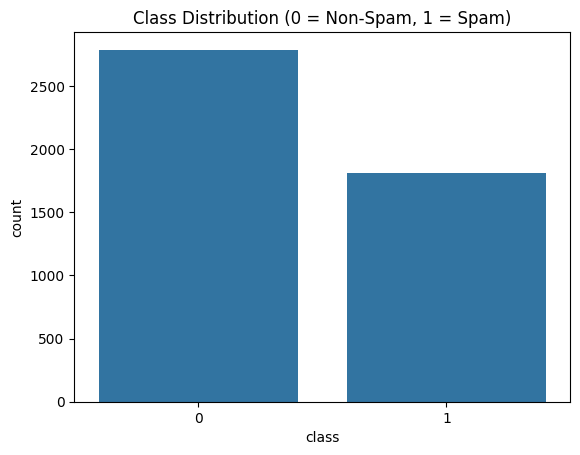

In [4]:
sns.countplot(x=data.iloc[:, -1])
plt.title("Class Distribution (0 = Non-Spam, 1 = Spam)")
plt.show()


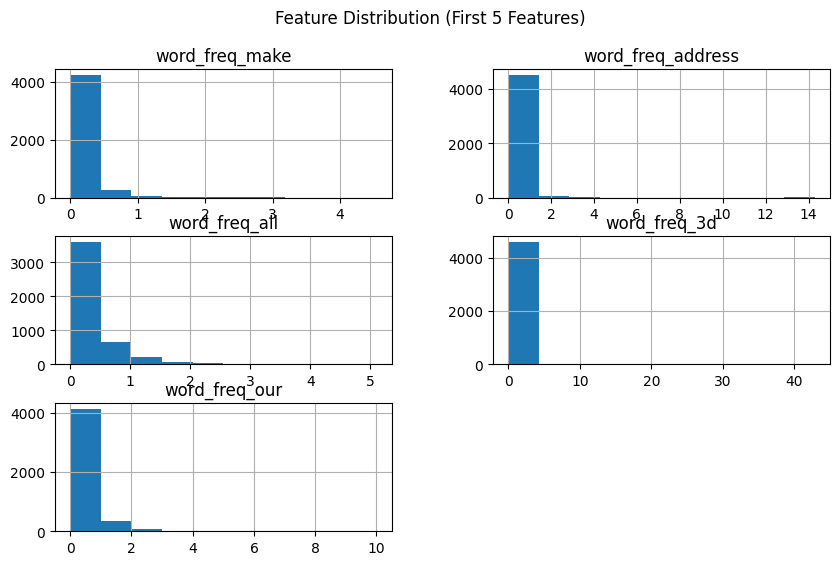

In [5]:
data.iloc[:, :5].hist(figsize=(10,6))
plt.suptitle("Feature Distribution (First 5 Features)")
plt.show()


In [6]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

X_train_mm, X_test_mm, _, _ = train_test_split(
    X_minmax, y, test_size=0.25, random_state=42, stratify=y
)


In [7]:
def evaluate(model, Xtr, Xte, ytr, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(Xte)
    pred_time = time.time() - t1

    cm = confusion_matrix(yte, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "Accuracy": accuracy_score(yte, y_pred),
        "Precision": precision_score(yte, y_pred),
        "Recall": recall_score(yte, y_pred),
        "F1 Score": f1_score(yte, y_pred),
        "Specificity": tn / (tn + fp),
        "False Positive Rate": fp / (fp + tn),
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }

    return metrics, cm


In [8]:
gnb = GaussianNB()
gnb_metrics, gnb_cm = evaluate(gnb, X_train, X_test, y_train, y_test)


In [9]:
mnb = MultinomialNB()
mnb_metrics, mnb_cm = evaluate(mnb, X_train_mm, X_test_mm, y_train, y_test)


In [10]:
bnb = BernoulliNB()
bnb_metrics, bnb_cm = evaluate(bnb, X_train_mm, X_test_mm, y_train, y_test)


In [11]:
nb_table = pd.DataFrame(
    [gnb_metrics, mnb_metrics, bnb_metrics],
    index=["Gaussian NB", "Multinomial NB", "Bernoulli NB"]
)
nb_table


,Accuracy,Precision,Recall,F1 Score,Specificity,False Positive Rate,Training Time (s),Prediction Time (s)
Gaussian NB,0.825369,0.707718,0.949339,0.810913,0.744620,0.255380,0.009084,0.002190
Multinomial NB,0.898349,0.951743,0.781938,0.858525,0.974175,0.025825,0.005251,0.001041
Bernoulli NB,0.883579,0.873832,0.823789,0.848073,0.922525,0.077475,0.009940,0.001895


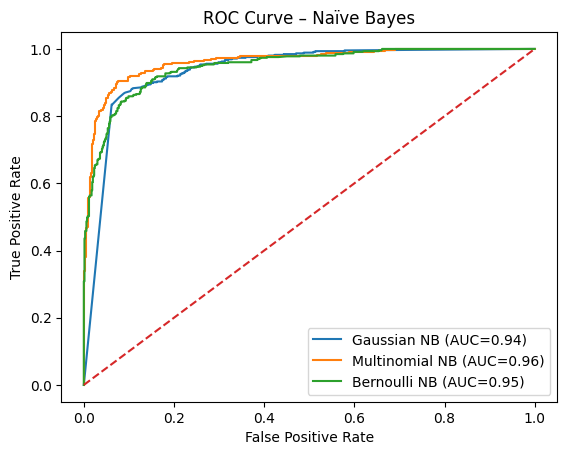

In [12]:
models = {
    "Gaussian NB": (gnb, X_test),
    "Multinomial NB": (mnb, X_test_mm),
    "Bernoulli NB": (bnb, X_test_mm)
}

for name, (model, Xte) in models.items():
    y_prob = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Naïve Bayes")
plt.legend()
plt.show()


In [13]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base_metrics, knn_base_cm = evaluate(
    knn_base, X_train, X_test, y_train, y_test
)


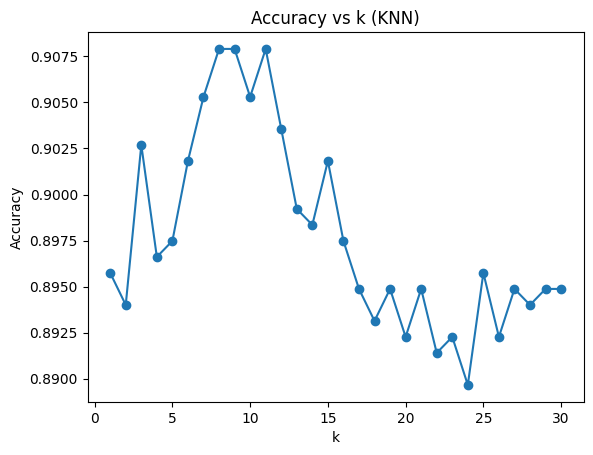

In [14]:
k_values = range(1, 31)
acc = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc.append(model.score(X_test, y_test))

plt.plot(k_values, acc, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k (KNN)")
plt.show()


In [15]:
param_grid = {
    "n_neighbors": range(1, 31),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': range(1, 31), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [16]:
rand = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
rand.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': range(1, 31), 'weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` def

In [17]:
tuning_table = pd.DataFrame({
    "Search Method": ["Grid Search", "Randomized Search"],
    "Best k": [
        grid.best_params_["n_neighbors"],
        rand.best_params_["n_neighbors"]
    ],
    "Best CV Accuracy": [grid.best_score_, rand.best_score_],
    "Best Parameters": [grid.best_params_, rand.best_params_]
})
tuning_table


,Search Method,Best k,Best CV Accuracy,Best Parameters
0,Grid Search,8,0.923188,"{'metric': 'manhattan', 'n_neighbors': 8, 'wei..."
1,Randomized Search,6,0.922319,"{'weights': 'distance', 'n_neighbors': 6, 'met..."


In [18]:
knn_kd = KNeighborsClassifier(**grid.best_params_, algorithm="kd_tree")
kd_metrics, kd_cm = evaluate(knn_kd, X_train, X_test, y_train, y_test)
pd.DataFrame(kd_metrics, index=["KDTree"])


,Accuracy,Precision,Recall,F1 Score,Specificity,False Positive Rate,Training Time (s),Prediction Time (s)
KDTree,0.923545,0.933649,0.867841,0.899543,0.959828,0.040172,0.049926,0.573689


In [19]:
knn_bt = KNeighborsClassifier(**grid.best_params_, algorithm="ball_tree")
bt_metrics, bt_cm = evaluate(knn_bt, X_train, X_test, y_train, y_test)
pd.DataFrame(bt_metrics, index=["BallTree"])


,Accuracy,Precision,Recall,F1 Score,Specificity,False Positive Rate,Training Time (s),Prediction Time (s)
BallTree,0.923545,0.933649,0.867841,0.899543,0.959828,0.040172,0.040814,0.472226


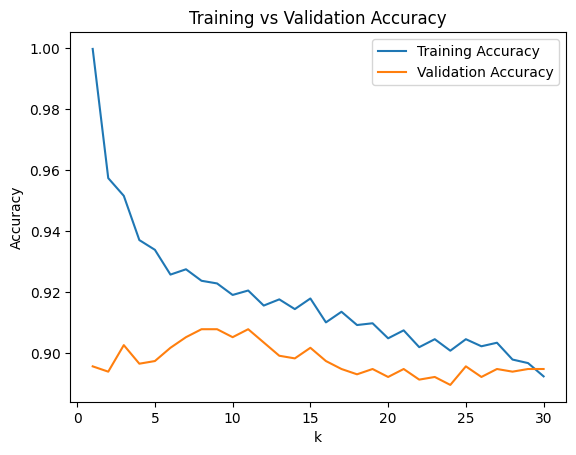

In [20]:
train_acc = []
val_acc = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    val_acc.append(model.score(X_test, y_test))

plt.plot(k_values, train_acc, label="Training Accuracy")
plt.plot(k_values, val_acc, label="Validation Accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()
